In [ ]:
import boto3
import pandas as pd
from sklearn.cluster import KMeans

In [ ]:
s3 = boto3.client('s3')
bucket = 'cust-seg-ygp'
key = 'rfm_scaled.csv'   # <-- scaled file name

obj = s3.get_object(Bucket=bucket, Key=key)
rfm_scaled = pd.read_csv(obj['Body'])

rfm_scaled.head()

In [ ]:
# X = your scaled RFM features
X = rfm_scaled[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']]

# create K-Means model with K = 4
kmeans = KMeans(n_clusters=4, random_state=42)

# fit the model and get cluster labels
rfm_scaled['Cluster'] = kmeans.fit_predict(X)

# preview results
rfm_scaled.head()

In [ ]:
rfm_scaled['Cluster'].value_counts()

Cluster
1    3836
0    2003
2      35
3       4
Name: count, dtype: int64

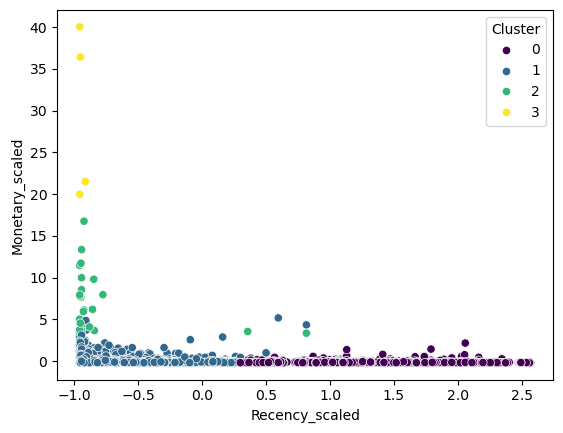

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=rfm_scaled,
    x='Recency_scaled',
    y='Monetary_scaled',
    hue='Cluster',
    palette='viridis'
)
plt.show()

In [ ]:
# Mapping old cluster numbers to new names
cluster_map = {
    1: 'A_Regular_Customers',
    0: 'B_Inactive_Customers',
    2: 'C_Good_Customers',
    3: 'D_VIP_Customers'
}

# Create a new column with renamed clusters
rfm_scaled['Cluster_Name'] = rfm_scaled['Cluster'].map(cluster_map)

rfm_scaled[['Cluster', 'Cluster_Name']].head()

In [ ]:
import io
csv_buffer = io.StringIO()

rfm_scaled.to_csv(csv_buffer, index=False)

s3.put_object(
    Bucket='cust-seg-ygp',
    Key='rfm_scaled_clusters_k4.csv',
    Body=csv_buffer.getvalue()
)

print("Saved rfm_scaled_clusters_k4.csv to S3.")

Saved rfm_scaled_clusters_k4.csv to S3.
